In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os 
os.chdir('..')

In [124]:
import torch
from sklearn.model_selection import train_test_split
from fq_model.final_fq import FQ
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, mean_squared_error
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

In [125]:
from regression.cal_house.cal_housing import CalHousing
X, y = CalHousing().get_data()

In [126]:
X.std(axis=0)

array([0.19955467, 0.22702395, 0.2468921 , 0.05557801, 0.06539025,
       0.03176044, 0.06286628, 0.13098059, 0.35502503])

In [127]:
y.std()

0.2380048790064407

In [128]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = "cpu"
print(device)
test_size=0.2
batch_size=400
random_state=17
num_epochs=100
rules=3
lr=0.0005

cuda


In [129]:

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.5,
                                                    random_state=random_state)
    
out_size = 1
print('out_size', out_size)

# Initialize and move model to GPU
model = FQ(in_features=X.shape[1], rules=rules, out_features=out_size, mid_layer_dim=9, task='regression', fuzzy_model='tsk', device=device).to(device)

# model._rule_initialization(X_train, y_train)


X_train_eval = X_train
X_test_eval = X_test
y_train_eval = y_train
y_test_eval = y_test

X_train = torch.Tensor(X_train).to(device)
X_test = torch.Tensor(X_test).to(device)
y_train = torch.Tensor(y_train).to(device)
y_test = torch.Tensor(y_test).to(device)


out_size 1


In [130]:
import torch.nn as nn

# Set up optimizer and loss function for pre-training
optimizer = optim.Adam(model.parameters(), lr=0.005)
loss_fn = nn.MSELoss()

# Pre-training loop
num_epochs_pretrain = 400
model.train()
for epoch in range(num_epochs_pretrain):
    total_loss = 0
    for i in range(0, len(X_train), batch_size):
        optimizer.zero_grad()
        batch_X = X_train[i:i+batch_size]
        reconstructed_X, cov_loss = model(batch_X, phase='pretrain')
        loss = loss_fn(reconstructed_X, batch_X) + cov_loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f'Epoch {epoch+1}, Pre-training Loss: {total_loss / len(X_test)}')


Epoch 1, Pre-training Loss: 0.023832735418398296
Epoch 2, Pre-training Loss: 0.03607780293754674
Epoch 3, Pre-training Loss: 0.04737553648301343
Epoch 4, Pre-training Loss: 0.044003943168593095
Epoch 5, Pre-training Loss: 0.04141284561418584
Epoch 6, Pre-training Loss: 0.04181277837097102
Epoch 7, Pre-training Loss: 0.043822642185688716
Epoch 8, Pre-training Loss: 0.044978654325107566
Epoch 9, Pre-training Loss: 0.04531282677136604
Epoch 10, Pre-training Loss: 0.045051974023731414
Epoch 11, Pre-training Loss: 0.04455285951140763
Epoch 12, Pre-training Loss: 0.043996957273204185
Epoch 13, Pre-training Loss: 0.043475471878163766
Epoch 14, Pre-training Loss: 0.043059836771549564
Epoch 15, Pre-training Loss: 0.04278833464515808
Epoch 16, Pre-training Loss: 0.04263536218585503
Epoch 17, Pre-training Loss: 0.042522190344523834
Epoch 18, Pre-training Loss: 0.042374044782181736
Epoch 19, Pre-training Loss: 0.04215450497817956
Epoch 20, Pre-training Loss: 0.04186009581312807
Epoch 21, Pre-train

In [135]:
train_loss = []
test_loss = []

num_epochs=2000

# Initialize Adam optimizer
optimizer = optim.Adam(model.parameters(), lr=lr)

# Store initial parameters
initial_params = {name: param.clone().detach() for name, param in model.named_parameters()}


for epoch in range(num_epochs):
    model.train()
    for i in range(0, len(X_train), batch_size):
    # for i in range(1):
        optimizer.zero_grad()
        batch_X, batch_y = X_train[i:i+batch_size], y_train[i:i+batch_size]
        outputs, cov_loss = model(batch_X)
        mse_loss = F.mse_loss(outputs, batch_y) + cov_loss
        total_loss = mse_loss  
        total_loss.backward()
        # print(model.tt.grad[0][0][0])
        optimizer.step()

    model.eval()
    with torch.no_grad():
        outputs, _ = model(X_test)
        outputs = outputs.cpu()
        mse_loss = mean_squared_error(y_test_eval, outputs, squared=False)
        total_loss = mse_loss
        test_loss.append(total_loss.item())
        #####
        outputs, _ = model(X_train)
        outputs = outputs.cpu()
        mse_loss = mean_squared_error(y_train_eval, outputs, squared=False)
        total_loss = mse_loss
        train_loss.append(total_loss.item())


# train_loss = np.sqrt(train_loss)
# test_loss = np.sqrt(test_loss)

# Calculate and print the average accuracy across all folds
min_RMSE = min(test_loss)
print("minimum test RMSE:", min_RMSE)
min_RMSE = min(train_loss)
print("minimum train RMSE:", min_RMSE)

minimum test RMSE: 0.12339346175668818
minimum train RMSE: 0.11925901690703258


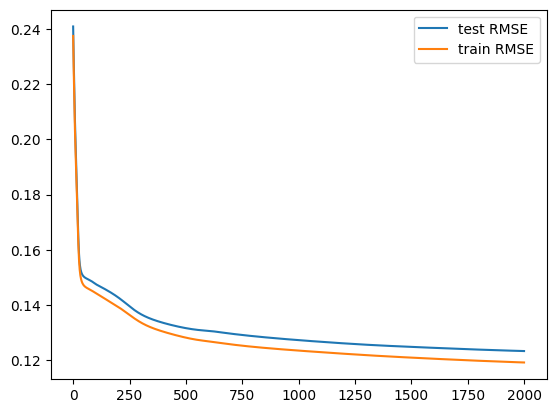

In [136]:
plt.plot(np.arange(len(test_loss)), test_loss)
plt.plot(np.arange(len(train_loss)), train_loss)
plt.legend(['test RMSE', 'train RMSE'])
plt.show()

In [ ]:
initial_params.items()

dict_items([('mean', tensor([[[ 0.5450,  1.4221,  0.4207],
         [-0.0953,  0.4840,  0.5173],
         [ 1.2523,  1.1685,  1.0074],
         [ 0.5715,  1.1436,  1.3676],
         [ 1.0226,  0.8465,  1.5929],
         [ 0.9235,  0.8257,  0.8727],
         [ 0.4516,  0.6872,  0.6311],
         [ 0.9209,  1.3486,  1.2069],
         [ 1.2649, -0.1157,  1.0417]]], device='cuda:0')), ('transition', tensor([[[-2.4491e+00, -5.1531e-01,  1.6123e-01, -1.9719e+00, -1.0314e+00,
           1.7175e+00,  2.1749e+00, -6.2023e-02, -3.3187e-01],
         [ 3.8055e+00,  1.7433e+00, -2.7004e-01,  2.6781e+00,  1.7460e+00,
          -2.5401e+00, -2.5308e+00,  3.2696e-01,  4.1872e-01],
         [-5.1733e-01,  4.4155e-02,  1.7375e-01, -6.7689e-01, -2.4683e-01,
           6.8312e-01,  6.5940e-01, -1.1148e-01,  1.6088e-01],
         [ 2.9972e-02,  1.9207e-01,  1.1184e-01,  1.4778e-01,  3.3973e-01,
           1.2791e-01,  8.8214e-03,  9.0921e-02,  2.8354e-01],
         [-1.4693e-02, -1.8475e-01,  6.9405e-02, 

In [ ]:
updated_params = {name: param.clone().detach() for name, param in model.named_parameters()}
updated_params

{'mean': tensor([[[ 0.7659,  1.3865,  0.3327],
          [-0.1016,  0.5648,  0.6554],
          [ 1.2585,  1.0514,  1.0994],
          [ 1.0440,  1.0202,  1.3921],
          [ 1.4168,  0.8697,  1.5105],
          [ 0.9882,  0.5845,  1.0265],
          [ 0.6169,  0.6548,  0.4352],
          [ 1.0006,  1.0779,  0.9892],
          [ 1.2670, -0.1137,  1.2101]]], device='cuda:0'),
 'transition': tensor([[[-3.3069e+00, -1.9551e+00, -1.1343e-01, -2.1644e+00, -6.6093e-01,
            1.9296e+00,  2.5106e+00,  7.7056e-03,  1.4294e-02],
          [ 5.0750e+00,  3.0274e+00, -2.9060e-01,  2.2451e+00,  2.4456e+00,
           -2.1011e+00, -2.1214e+00,  3.7055e-01,  5.8715e-01],
          [-4.4345e-01,  2.5745e-01,  8.8791e-01, -5.2505e-01, -8.0155e-01,
            5.1162e-01,  4.1366e-01, -4.6461e-01,  2.3781e-01],
          [ 1.7521e-01,  2.3474e-02,  2.7451e-01,  4.8914e-02,  1.0352e-01,
            2.0535e-01, -1.6392e-02,  7.1805e-02,  6.5745e-01],
          [ 8.4809e-02, -7.9706e-01, -2.0409e-0

In [ ]:
# After training, you can get the updated parameters
updated_params = {name: param.clone().detach() for name, param in model.named_parameters()}

# # Calculate the difference between initial and updated parameters
# param_diff = {name: updated - initial for name, (updated, initial) in zip(updated_params.items(), initial_params.items())}

# Print the difference
for name, updated in updated_params.items():
    print(name)
    print(updated - initial_params[name])

mean
tensor([[[ 0.2209, -0.0356, -0.0881],
         [-0.0063,  0.0808,  0.1381],
         [ 0.0062, -0.1171,  0.0920],
         [ 0.4725, -0.1235,  0.0244],
         [ 0.3942,  0.0232, -0.0824],
         [ 0.0647, -0.2412,  0.1538],
         [ 0.1653, -0.0324, -0.1958],
         [ 0.0797, -0.2707, -0.2177],
         [ 0.0020,  0.0020,  0.1684]]], device='cuda:0')
transition
tensor([[[-8.5775e-01, -1.4398e+00, -2.7466e-01, -1.9253e-01,  3.7050e-01,
           2.1201e-01,  3.3564e-01,  6.9729e-02,  3.4616e-01],
         [ 1.2695e+00,  1.2841e+00, -2.0563e-02, -4.3299e-01,  6.9963e-01,
           4.3899e-01,  4.0935e-01,  4.3595e-02,  1.6843e-01],
         [ 7.3871e-02,  2.1330e-01,  7.1416e-01,  1.5184e-01, -5.5472e-01,
          -1.7150e-01, -2.4574e-01, -3.5313e-01,  7.6924e-02],
         [ 1.4524e-01, -1.6860e-01,  1.6266e-01, -9.8863e-02, -2.3621e-01,
           7.7434e-02, -2.5213e-02, -1.9117e-02,  3.7391e-01],
         [ 9.9502e-02, -6.1230e-01, -8.9814e-02,  1.2850e-01, -4.4821e-

In [ ]:
model.mean

Parameter containing:
tensor([[[ 0.7659,  1.3865,  0.3327],
         [-0.1016,  0.5648,  0.6554],
         [ 1.2585,  1.0514,  1.0994],
         [ 1.0440,  1.0202,  1.3921],
         [ 1.4168,  0.8697,  1.5105],
         [ 0.9882,  0.5845,  1.0265],
         [ 0.6169,  0.6548,  0.4352],
         [ 1.0006,  1.0779,  0.9892],
         [ 1.2670, -0.1137,  1.2101]]], device='cuda:0', requires_grad=True)

In [ ]:
torch.tanh(model.tt)

tensor([[[-0.3357,  0.7197, -0.5659],
         [-0.4059,  0.7623,  0.8007],
         [-0.4224, -0.6142,  0.5838],
         [-0.2866, -0.4816,  0.3164],
         [-0.1576,  0.8622,  0.5020],
         [-0.2503,  0.8476,  0.4740],
         [-0.2538, -0.7374, -0.6116],
         [-0.7373, -0.6881,  0.7262],
         [ 0.5198,  0.3999,  0.4275]]], device='cuda:0',
       grad_fn=<TanhBackward0>)

In [ ]:
model.linear.weight

AttributeError: 'FQ' object has no attribute 'linear'

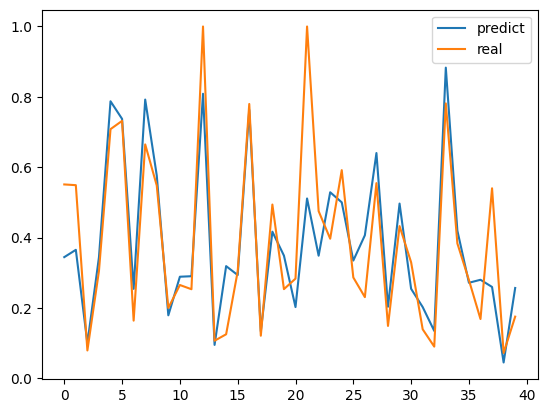

In [ ]:
model.eval()
with torch.no_grad():
    plt.plot(np.array(model(X_test).to('cpu'))[40:80])
    plt.plot(y_test.cpu()[40:80])
    plt.legend(['predict', 'real'])

In [ ]:
np.sqrt(mean_squared_error(np.array(model(X_test).detach().to('cpu')), y_test.cpu()))

0.13040848

IRIS = 94</br>
Cryotheraphy = 95</br>
Immunotherapy = 89</br>
Haberman = 74</br>
Wine = 89</br>
heart = 85</br>
CAL HOUSING : tsk:0.34, mamdani=0.33